In [48]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [49]:
# 1) Load dataset - update path if needed
df = pd.read_csv("uber.csv")   # upload and/or adjust path

# Quick preview
print("Rows,cols:", df.shape)
display(df.head())

Rows,cols: (200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [50]:
# Basic preprocessing
# - drop duplicates
# - remove obvious bad fares: fare_amount <= 0
# - convert pickup_datetime
df = df.drop_duplicates()
df = df[df['fare_amount'] > 0].copy()
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df = df.dropna(subset=['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 
                       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'])


In [51]:
# Feature engineering: compute haversine distance
def haversine(lon1, lat1, lon2, lat2):
    # all args in degrees
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

df['distance_km'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                              df['dropoff_longitude'], df['dropoff_latitude'])


In [52]:
# Extract time features
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month

In [53]:
# Handle passenger_count outliers (clip to sensible range)
df['passenger_count'] = df['passenger_count'].clip(1, 6)

# Identify outliers (IQR method) for fare_amount and distance
def iqr_filter(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

f_low, f_up = iqr_filter(df['fare_amount'])
d_low, d_up = iqr_filter(df['distance_km'])


In [54]:
print("Fare bounds:", f_low, f_up)
print("Distance bounds:", d_low, d_up)


Fare bounds: -3.75 22.25
Distance bounds: -2.7743876580157423 7.8649706100314045


In [55]:
# Mark outliers
df['fare_outlier'] = ((df['fare_amount'] < f_low) | (df['fare_amount'] > f_up))
df['dist_outlier'] = ((df['distance_km'] < d_low) | (df['distance_km'] > d_up))
print("Fare outliers:", df['fare_outlier'].sum(), "Distance outliers:", df['dist_outlier'].sum())

# Option: drop extreme distance/fare outliers
df_clean = df[(~df['fare_outlier']) & (~df['dist_outlier'])].copy()
print("After dropping outliers:", df_clean.shape)


Fare outliers: 17155 Distance outliers: 16752
After dropping outliers: (179374, 15)


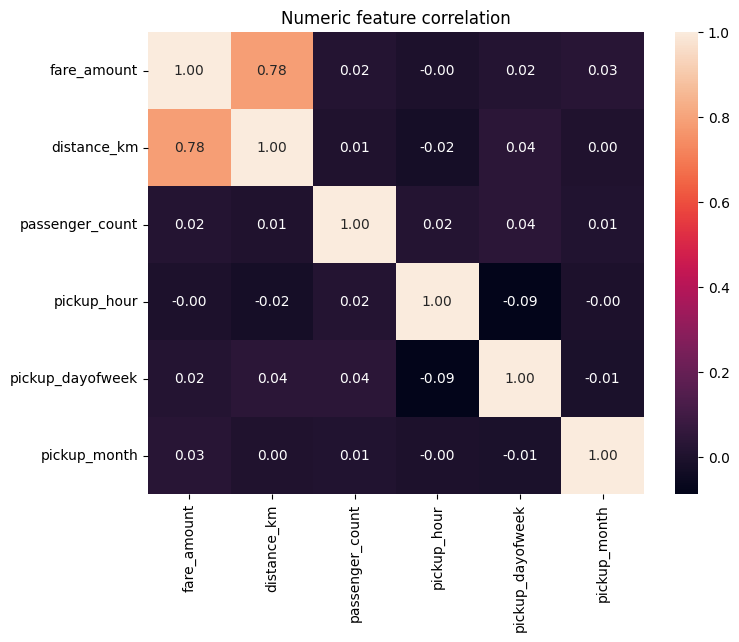

In [56]:
# Correlation matrix (numeric)
num_cols = ['fare_amount','distance_km','passenger_count','pickup_hour','pickup_dayofweek','pickup_month']
corr = df_clean[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Numeric feature correlation")
plt.show()

# Prepare features and target
X = df_clean[['distance_km','passenger_count','pickup_hour','pickup_dayofweek','pickup_month']]
y = df_clean['fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard scaler for numerical features
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, X.columns)
])

In [57]:
# Function to fit, predict and evaluate model and return metrics
def eval_model(model, name):
    pipe = Pipeline([
        ('pre', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    print(f"{name} - R2: {r2:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")
    return {'model': name, 'r2': r2, 'mse': mse, 'rmse': rmse, 'preds': preds, 'pipe': pipe}

results = []



In [58]:
# i) Linear Regression
results.append(eval_model(LinearRegression(), "Linear Regression"))


Linear Regression - R2: 0.6251, MSE: 5.9424, RMSE: 2.4377


In [59]:
# ii) Random Forest Regression (default; you can GridSearch for hyperparams)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
results.append(eval_model(rf, "Random Forest"))

Random Forest - R2: 0.6366, MSE: 5.7589, RMSE: 2.3998


In [60]:
# iii) XGBRegressor
xg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, n_jobs=4, objective='reg:squarederror')
results.append(eval_model(xg, "XGBoost"))

XGBoost - R2: 0.6756, MSE: 5.1410, RMSE: 2.2674


In [61]:
# iv) Elastic Net
en = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=2000)
results.append(eval_model(en, "ElasticNet"))


ElasticNet - R2: 0.4986, MSE: 7.9472, RMSE: 2.8191


In [62]:
# v) Logistic Regression -> Not applicable for continuous prediction
# OPTIONAL: create binary target e.g. fare > median
median_fare = y_train.median()
y_train_bin = (y_train > median_fare).astype(int)
y_test_bin = (y_test > median_fare).astype(int)
log_pipe = Pipeline([('pre', preprocessor), ('model', LogisticRegression(max_iter=1000))])
log_pipe.fit(X_train, y_train_bin)
log_preds = log_pipe.predict(X_test)
from sklearn.metrics import accuracy_score
log_acc = accuracy_score(y_test_bin, log_preds)
print("Logistic Regression (binary task) - accuracy on fare > median:", log_acc)
# record as separate evaluation
results.append({'model': 'Logistic Regression (binary->accuracy)', 'r2': None, 'mse': None, 'rmse': None, 'accuracy': log_acc})


Logistic Regression (binary task) - accuracy on fare > median: 0.8322787456445992


In [63]:
# vi) Poisson Regression using statsmodels (GLM)
# Poisson is for count-like non-negative; we fit using log link
# Add small constant to avoid zeros
train_df = X_train.copy(); train_df['fare_amount'] = y_train
test_df = X_test.copy(); test_df['fare_amount'] = y_test
# Build formula
formula = 'fare_amount ~ distance_km + passenger_count + pickup_hour + pickup_dayofweek + pickup_month'
poisson_model = smf.glm(formula=formula, data=train_df, family=sm.families.Poisson()).fit(maxiter=100)
print(poisson_model.summary())
poisson_preds = poisson_model.predict(test_df)
poisson_r2 = r2_score(y_test, poisson_preds)
poisson_mse = mean_squared_error(y_test, poisson_preds)
print("Poisson GLM - R2:", poisson_r2, "MSE:", poisson_mse, "RMSE:", np.sqrt(poisson_mse))
results.append({'model': 'Poisson GLM', 'r2': poisson_r2, 'mse': poisson_mse, 'rmse': np.sqrt(poisson_mse), 'preds': poisson_preds})

                 Generalized Linear Model Regression Results                  
Dep. Variable:            fare_amount   No. Observations:               143499
Model:                            GLM   Df Residuals:                   143493
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.3190e+05
Date:                Tue, 04 Nov 2025   Deviance:                       98829.
Time:                        00:22:33   Pearson chi2:                 1.11e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.6260
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.6484      0.004  

In [64]:
# vii) Negative Binomial Regression (statsmodels)
nb_model = smf.glm(formula=formula, data=train_df, family=sm.families.NegativeBinomial()).fit()
print(nb_model.summary())
nb_preds = nb_model.predict(test_df)
nb_r2 = r2_score(y_test, nb_preds); nb_mse = mean_squared_error(y_test, nb_preds)
print("Negative Binomial GLM - R2:", nb_r2, "MSE:", nb_mse, "RMSE:", np.sqrt(nb_mse))
results.append({'model': 'NegBin GLM', 'r2': nb_r2, 'mse': nb_mse, 'rmse': np.sqrt(nb_mse), 'preds': nb_preds})


                 Generalized Linear Model Regression Results                  
Dep. Variable:            fare_amount   No. Observations:               143499
Model:                            GLM   Df Residuals:                   143493
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.5616e+05
Date:                Tue, 04 Nov 2025   Deviance:                       10662.
Time:                        00:22:33   Pearson chi2:                 1.33e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.09234
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.6243      0.011  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [65]:
# Summarize results into DataFrame
rows = []
for r in results:
    rows.append({
        'Model': r['model'],
        'R2': r.get('r2'),
        'MSE': r.get('mse'),
        'RMSE': r.get('rmse'),
        'Extra': 'accuracy' if r.get('accuracy') else ''
    })
res_df = pd.DataFrame(rows)
display(res_df)


,Model,R2,MSE,RMSE,Extra
0,Linear Regression,0.625073,5.942369,2.437697,
1,Random Forest,0.636649,5.758900,2.399771,
2,XGBoost,0.675635,5.140992,2.267375,
3,ElasticNet,0.498584,7.947152,2.819069,
4,Logistic Regression (binary->accuracy),NaN,NaN,NaN,accuracy
5,Poisson GLM,0.603626,6.282287,2.506449,
6,NegBin GLM,0.596020,6.402846,2.530385,


Text(0.5, 1.0, 'R2 by Model')

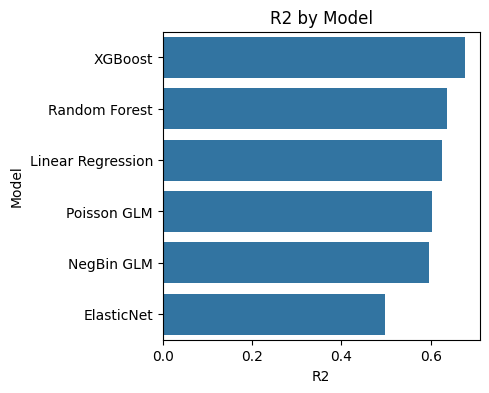

In [66]:
# Plot comparison (R2 and RMSE)
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plot_df = res_df.dropna(subset=['R2'])
sns.barplot(x='R2', y='Model', data=plot_df.sort_values('R2', ascending=False))
plt.title("R2 by Model")


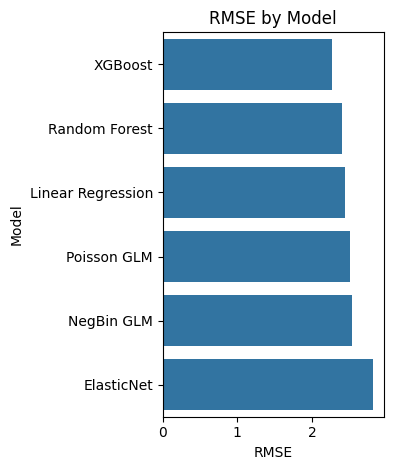

In [67]:
plt.subplot(1,2,2)
plot_df2 = res_df.dropna(subset=['RMSE'])
sns.barplot(x='RMSE', y='Model', data=plot_df2.sort_values('RMSE'))
plt.title("RMSE by Model")
plt.tight_layout()
plt.show()

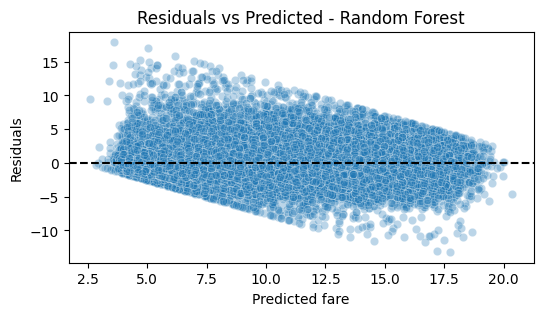

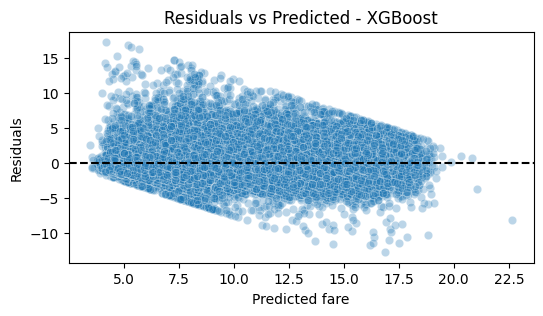

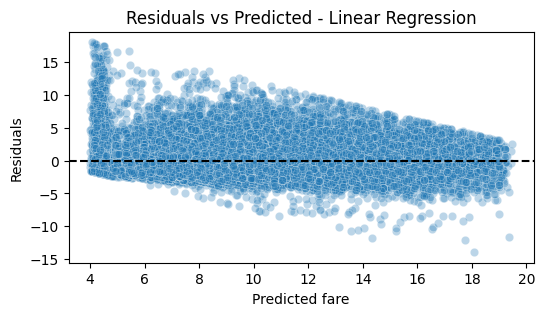

In [68]:
# Residual plots for top numeric models (e.g., Random Forest, XGBoost, Linear)
for name in ['Random Forest', 'XGBoost', 'Linear Regression']:
    rec = next((r for r in results if r['model']==name), None)
    if rec:
        preds = rec['preds']
        resids = y_test - preds
        plt.figure(figsize=(6,3))
        sns.scatterplot(x=preds, y=resids, alpha=0.3)
        plt.axhline(0, color='black', linestyle='--')
        plt.title(f"Residuals vs Predicted - {name}")
        plt.xlabel("Predicted fare"); plt.ylabel("Residuals")
        plt.show()